In [29]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing  import LabelEncoder
import pickle  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression


df=pd.read_csv("salary_dataset_1000.csv")
df

,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,NaN,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000


In [30]:
df.head(10)

,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,NaN,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
5,49.0,7.4,Bachelors,Hyderabad,leadership powerbi sql,910000
6,39.0,6.3,Bachelors,Delhi,management leadership ml sql powerbi python re...,1005000
7,33.0,4.6,Bachelors,Bangalore,powerbi management,830000
8,36.0,11.1,Masters,Pune,sql ml python powerbi leadership ai,1475000
9,46.0,15.7,Bachelors,Hyderabad,research powerbi python,1310000


In [31]:
df.tail(10)

,age,experience,education,city,skills,salary
990,45.0,8.8,Masters,Bangalore,excel powerbi ml ai leadership research,1200000
991,35.0,8.7,Masters,Delhi,leadership dl research sql,1330000
992,32.0,7.5,Bachelors,Pune,sql management ml leadership excel dl,960000
993,23.0,0.0,Masters,Mumbai,leadership,430000
994,35.0,8.1,NaN,Pune,sql ai ml powerbi excel management,830000
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000
999,50.0,9.5,Masters,Pune,ml management python,1325000


In [32]:
df.describe()

,age,experience,salary
count,957.000000,1000.000000,1.000000e+03
mean,35.153605,8.032400,1.104645e+06
std,9.291785,5.154184,4.414132e+05
min,20.000000,0.000000,0.000000e+00
25%,27.000000,3.600000,8.350000e+05
50%,35.000000,7.100000,1.115000e+06
75%,44.000000,11.800000,1.405000e+06
max,50.000000,20.000000,2.000000e+06


In [33]:
df.shape

(1000, 6)

In [34]:
df.isnull().sum()

age           43
experience     0
education     99
city           0
skills        51
salary         0
dtype: int64

<Axes: xlabel='salary', ylabel='Count'>

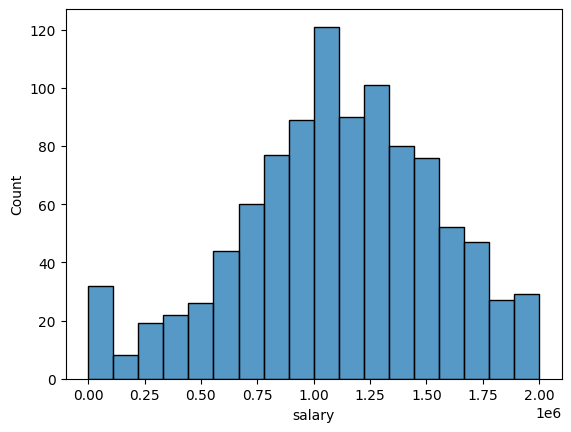

In [35]:
sns.histplot(df["salary"])

<Axes: xlabel='age', ylabel='Count'>

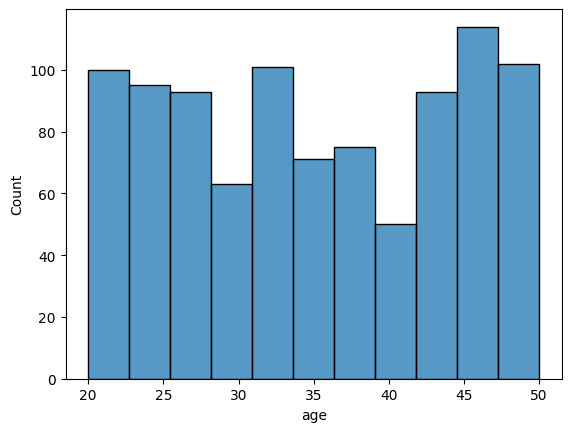

In [36]:
sns.histplot(df["age"])


<Axes: ylabel='experience'>

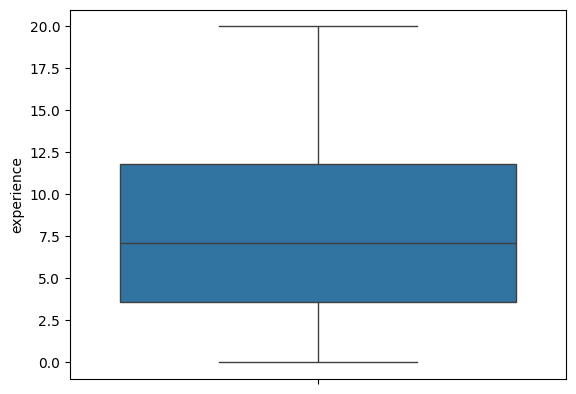

In [37]:
sns.boxplot(df["experience"])

<Axes: ylabel='salary'>

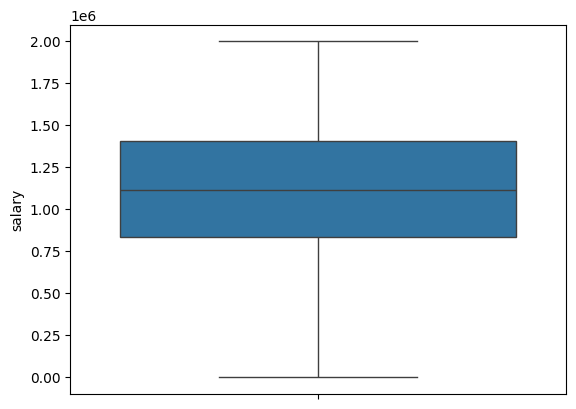

In [38]:
sns.boxplot(df["salary"])

<Axes: xlabel='experience', ylabel='salary'>

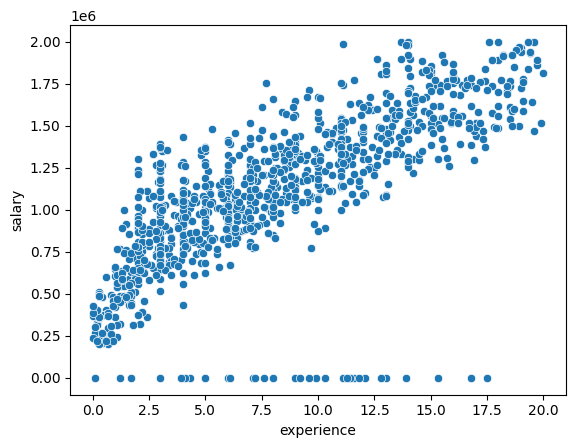

In [39]:
sns.scatterplot(x=df["experience"], y=df["salary"], data=df)

<Axes: xlabel='education', ylabel='salary'>

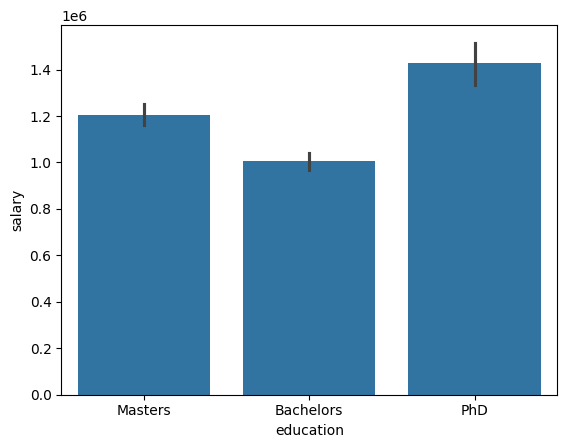

In [40]:
sns.barplot(x=df["education"], y=df["salary"], data=df)

In [41]:
df

,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,NaN,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000


In [42]:
df["age"].fillna(df["age"].mean(), inplace=True)
df

C:\Users\jaine\AppData\Local\Temp\ipykernel_16132\3166691681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(), inplace=True)


,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,NaN,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000


In [43]:
df["education"].fillna("none",inplace=True)
df

C:\Users\jaine\AppData\Local\Temp\ipykernel_16132\3146062917.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].fillna("none",inplace=True)


,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,none,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000


In [44]:
df.groupby("city")["salary"].sum()

city
Ahmedabad    106300000
Bangalore    267815000
Delhi        217705000
Hyderabad    147690000
Mumbai       234765000
Pune         130370000
Name: salary, dtype: int64

In [45]:
df.groupby("education")["salary"].sum()

education
Bachelors    446585000
Masters      439060000
PhD          133030000
none          85970000
Name: salary, dtype: int64

In [46]:
df.groupby("education")["experience"].mean()

education
Bachelors    7.940541
Masters      8.130769
PhD          8.291398
none         7.839394
Name: experience, dtype: float64

In [47]:
df.groupby("education")["age"].mean()

education
Bachelors    35.392746
Masters      34.965121
PhD          35.324232
none         34.613818
Name: age, dtype: float64

In [48]:
df.groupby("city")["age"].mean()

city
Ahmedabad    35.739216
Bangalore    35.577424
Delhi        34.288256
Hyderabad    35.171873
Mumbai       34.661383
Pune         36.118574
Name: age, dtype: float64

In [49]:
df["skills"].fillna("none",inplace=True)
df

C:\Users\jaine\AppData\Local\Temp\ipykernel_16132\1673634771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["skills"].fillna("none",inplace=True)


,age,experience,education,city,skills,salary
0,21.0,3.0,Masters,Mumbai,python excel,925000
1,46.0,6.9,Bachelors,Ahmedabad,ml python management leadership ai excel,910000
2,43.0,8.5,Masters,Ahmedabad,dl sql ml excel management python powerbi,1235000
3,46.0,7.7,none,Bangalore,python excel research dl leadership,925000
4,39.0,10.8,Masters,Delhi,dl python management,1485000
...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,ai ml research leadership python,1360000
996,48.0,1.0,Masters,Delhi,research excel ai sql,660000
997,23.0,5.0,Masters,Hyderabad,leadership sql dl ml management,0
998,44.0,10.1,Masters,Hyderabad,python dl leadership research,1295000


In [50]:
df.isnull().sum()

age           0
experience    0
education     0
city          0
skills        0
salary        0
dtype: int64

In [51]:
df = df.join(df["skills"].str.get_dummies(sep=" "))
df.drop("skills", axis=1, inplace=True)
df



,age,experience,education,city,salary,ai,dl,excel,leadership,management,ml,none,powerbi,python,research,sql
0,21.0,3.0,Masters,Mumbai,925000,0,0,1,0,0,0,0,0,1,0,0
1,46.0,6.9,Bachelors,Ahmedabad,910000,1,0,1,1,1,1,0,0,1,0,0
2,43.0,8.5,Masters,Ahmedabad,1235000,0,1,1,0,1,1,0,1,1,0,1
3,46.0,7.7,none,Bangalore,925000,0,1,1,1,0,0,0,0,1,1,0
4,39.0,10.8,Masters,Delhi,1485000,0,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27.0,9.0,Masters,Mumbai,1360000,1,0,0,1,0,1,0,0,1,1,0
996,48.0,1.0,Masters,Delhi,660000,1,0,1,0,0,0,0,0,0,1,1
997,23.0,5.0,Masters,Hyderabad,0,0,1,0,1,1,1,0,0,0,0,1
998,44.0,10.1,Masters,Hyderabad,1295000,0,1,0,1,0,0,0,0,1,1,0


In [52]:
df["city"]=df["city"].map({"Mumbai":0,"Ahmedabad":1,"Bangalore":2,"Delhi":3,"Hyderabad":4,"Pune":5})
df

,age,experience,education,city,salary,ai,dl,excel,leadership,management,ml,none,powerbi,python,research,sql
0,21.0,3.0,Masters,0,925000,0,0,1,0,0,0,0,0,1,0,0
1,46.0,6.9,Bachelors,1,910000,1,0,1,1,1,1,0,0,1,0,0
2,43.0,8.5,Masters,1,1235000,0,1,1,0,1,1,0,1,1,0,1
3,46.0,7.7,none,2,925000,0,1,1,1,0,0,0,0,1,1,0
4,39.0,10.8,Masters,3,1485000,0,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27.0,9.0,Masters,0,1360000,1,0,0,1,0,1,0,0,1,1,0
996,48.0,1.0,Masters,3,660000,1,0,1,0,0,0,0,0,0,1,1
997,23.0,5.0,Masters,4,0,0,1,0,1,1,1,0,0,0,0,1
998,44.0,10.1,Masters,4,1295000,0,1,0,1,0,0,0,0,1,1,0


In [53]:
le=LabelEncoder()
df["education"]=le.fit_transform(df["education"])
df

,age,experience,education,city,salary,ai,dl,excel,leadership,management,ml,none,powerbi,python,research,sql
0,21.0,3.0,1,0,925000,0,0,1,0,0,0,0,0,1,0,0
1,46.0,6.9,0,1,910000,1,0,1,1,1,1,0,0,1,0,0
2,43.0,8.5,1,1,1235000,0,1,1,0,1,1,0,1,1,0,1
3,46.0,7.7,3,2,925000,0,1,1,1,0,0,0,0,1,1,0
4,39.0,10.8,1,3,1485000,0,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27.0,9.0,1,0,1360000,1,0,0,1,0,1,0,0,1,1,0
996,48.0,1.0,1,3,660000,1,0,1,0,0,0,0,0,0,1,1
997,23.0,5.0,1,4,0,0,1,0,1,1,1,0,0,0,0,1
998,44.0,10.1,1,4,1295000,0,1,0,1,0,0,0,0,1,1,0


In [54]:
X=df[["age","experience","education","city","ai","dl","ml","python"]]
y=df["salary"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
predict=model.predict(X_test)
print(predict)

[ 747288.24004566  936871.36994472 1193883.00528548 1839721.72001236
  910463.25162982 1545183.20850456 1221928.98976977 1352000.70268612
 1352647.83666291 1194506.05901636 1758072.63589715  540005.234104
 1342998.47400028  469145.17281828  631138.10050252 1485185.65330217
  937560.11892248 1366158.98191248 1242747.30777575  953694.56095617
 1469842.12287321 1011661.39655266  591067.98479671  955993.66001064
 1041128.87104117  716485.566592   1419055.2302055  1364082.57038658
 1082682.98257598  929318.11797371  783985.00880522 1550438.91701151
 1590128.64967607 1130938.77788971 1387039.32772629 1431330.34833493
  966094.24791201 1373271.89626307 1116886.477833    609285.87750811
 1596230.78231288  553963.95690531 1025534.47617031  943356.50414991
 1738712.6517533   824487.08768334 1681486.48227878  947309.52699612
 1246535.27749563 1435831.54287645 1254073.37999932  719364.32380141
 1037596.29988468 1124348.24771783 1660611.23713059 1557865.50309458
  768574.84725274  777659.28212167  

In [56]:

MAE=mean_absolute_error(y_test,predict)
print("MAE is",MAE)

MSE=mean_squared_error(y_test,predict)
print("MSE is",MSE)

RMSE=root_mean_squared_error(y_test,predict)
print("RMSE is",RMSE)

MAE is 192362.6377021681
MSE is 94918810683.80695
RMSE is 308088.96553399466


In [57]:
rf= RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train,y_train)
predict1=rf.predict(X_test)
print(predict1)

[ 997781.16281605  701199.44527466 1161279.18756372 1808092.19032894
  881099.30398008 1686556.77632752 1162068.4267023  1206209.26421761
 1323155.6690987  1264834.58734578 1648139.58328564  391629.80534229
 1206284.07199812  306340.0756548   482662.14031188 1465460.88624517
  902370.34683177 1429125.70860293 1174024.7613735  1198115.69927851
 1482205.45644143 1125119.10383201  463053.23730391  897749.21377939
 1016662.20931972  780424.42285144 1385795.66538181 1638480.77392864
 1251477.06108293  897534.00108859 1011069.66439395 1643965.55985391
 1481112.55010148 1177014.0403987  1559224.6546534  1199745.19364252
  955500.39143338 1354989.88193484  925892.33729384  776755.41344912
 1496138.55591975  393824.17536208 1080396.38744924  908788.66116852
 1757032.09053928 1013055.80973283 1742830.09666878  793989.40543876
 1157604.29380574 1619027.59376044 1040322.63465593  784606.83579693
 1000679.2861505  1217416.83813509 1739683.87948951 1465671.85453982
  765706.81960971  905781.9948287 

In [58]:
MAE=mean_absolute_error(y_test,predict1)
print("MAE is",MAE)

MSE=mean_squared_error(y_test,predict1)
print("MSE is",MSE)

RMSE=root_mean_squared_error(y_test,predict1)
print("RMSE is",RMSE)

MAE is 135561.93737589635
MSE is 70867168497.81866
RMSE is 266208.8813278375


In [59]:
xg=XGBRegressor()
xg.fit(X_train,y_train)
predict2=xg.predict(X_test)
print(predict2)

[8.86222688e+05 8.22659625e+05 1.23614262e+06 1.81870288e+06
 7.58302875e+05 1.24943812e+06 1.31421775e+06 8.56671562e+05
 1.45065150e+06 1.43037812e+06 1.62067912e+06 3.86584719e+05
 1.25099600e+06 3.01785250e+05 2.75916719e+05 1.46108888e+06
 8.06270312e+05 1.39191888e+06 1.02855900e+06 1.39928612e+06
 1.38234250e+06 1.21488100e+06 4.91886125e+05 7.31074625e+05
 1.16589088e+06 7.93547000e+05 1.46914925e+06 1.57030012e+06
 9.96473000e+05 9.03162125e+05 1.02630794e+06 1.80491938e+06
 1.53892125e+06 1.33878012e+06 1.62184188e+06 1.33931500e+06
 1.11174888e+06 1.19998725e+06 9.38509062e+05 8.11645500e+05
 1.46526500e+06 3.40737625e+05 1.10198012e+06 1.03947362e+06
 1.79428075e+06 1.04706531e+06 1.94038412e+06 8.32224000e+05
 1.19182875e+06 1.69800762e+06 1.12672212e+06 6.91830812e+05
 1.02347556e+06 1.30287000e+06 1.87087250e+06 1.53359975e+06
 8.75343688e+05 1.00600731e+06 7.86066812e+05 1.21726988e+06
 2.56524953e+05 5.34091812e+05 1.58981625e+06 8.86714062e+05
 1.58967800e+06 5.141246

In [60]:
MAE=mean_absolute_error(y_test,predict2)
print("MAE is",MAE)

MSE=mean_squared_error(y_test,predict2)
print("MSE is",MSE)

RMSE=root_mean_squared_error(y_test,predict2)
print("RMSE is",RMSE)

MAE is 150334.484375
MSE is 87726891008.0
RMSE is 296187.25


In [61]:
train_pred1 = rf.predict(X_train)
test_pred1 = rf.predict(X_test)

print("Train RMSE:", root_mean_squared_error(y_train, train_pred1))
print("Test RMSE:", root_mean_squared_error(y_test, test_pred1))

Train RMSE: 224744.1500231891
Test RMSE: 266208.8813278375


In [62]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train RMSE:", root_mean_squared_error(y_train, train_pred))
print("Test RMSE:",  root_mean_squared_error(y_test, test_pred))

Train RMSE: 274142.41544102976
Test RMSE: 308088.96553399466


In [63]:
train_pred2 = xg.predict(X_train)
test_pred2 = xg.predict(X_test)

print("Train RMSE:", root_mean_squared_error(y_train, train_pred2))
print("Test RMSE:",  root_mean_squared_error(y_test, test_pred2))

Train RMSE: 38050.8125
Test RMSE: 296187.25


In [64]:

selector = SelectKBest(score_func=f_regression, k=6)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Best Features:", selected_features)

Best Features: Index(['age', 'experience', 'ai', 'dl', 'ml', 'python'], dtype='object')


In [65]:
rf= RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

scores = cross_val_score(rf, X, y, cv=5, scoring="neg_mean_squared_error")

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE scores: [306767.78509687 285977.33415761 252447.70251187 219229.35164159
 203686.26940595]
Average RMSE: 253621.6885627765


In [66]:
xg= XGBRegressor()

scores = cross_val_score(xg, X, y, cv=5, scoring="neg_mean_squared_error")

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE scores: [322026.54300539 310223.91706637 303942.36758965 268593.71894369
 263701.49815274]
Average RMSE: 293697.60895156546


In [67]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

rf= RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

grid = GridSearchCV(rf, param_grid, cv=5, scoring="neg_mean_squared_error")

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 50}


In [71]:

pickle.dump(model, open("salary_model.pkl", "wb"))


In [72]:
print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [73]:
model.predict([[18,4,1,1,1,0,0,0]])

C:\Users\jaine\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([888831.25042482])